In [181]:
import matplotlib.pyplot as plt
import pickle
import json
import numpy as np

In [182]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def compute_run_metrics(run_data_list):
    all_runs = []
    for run_data in run_data_list:
        metrics = [j['priority_alignment'] for j in run_data['timestep_metrics']]
        all_runs.append(metrics)
    return np.array(all_runs)

### Basic adversarial pressure

In [183]:
# --- Load all models ---
gpt_4o_mini_data = [
    load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run5_46.json"),
]

gpt_5_mini_data = [
    load_json("../data/basic/adv_pressure/gpt-5-mini/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5-mini/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5-mini/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5-mini/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5-mini/checkpoint_run5_46.json"),
]

gpt_5_1_data = [
    load_json("../data/basic/adv_pressure/gpt-5.1/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5.1/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5.1/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5.1/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/gpt-5.1/checkpoint_run5_46.json"),
]

qwen_235_data = [
    load_json("../data/basic/adv_pressure/qwen3-235b/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/qwen3-235b/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/qwen3-235b/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/qwen3-235b/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/qwen3-235b/checkpoint_run5_46.json"),
]

gemini_data = [
    load_json("../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run5_46.json"),
]

gemini_thinking_data = [
    load_json("../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run5_46.json"),
]

claude_data = [
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run5_46.json"),
]

claude_think_data = [
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run1_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run2_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run3_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run4_46.json"),
    load_json("../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run5_46.json"),
]

# --- Compute metrics ---
gpt_4o_mini = compute_run_metrics(gpt_4o_mini_data)
gpt_5_mini = compute_run_metrics(gpt_5_mini_data)
gpt_5_1 = compute_run_metrics(gpt_5_1_data)
qwen_235 = compute_run_metrics(qwen_235_data)
gemini = compute_run_metrics(gemini_data)
gemini_thinking = compute_run_metrics(gemini_thinking_data)
claude = compute_run_metrics(claude_data)

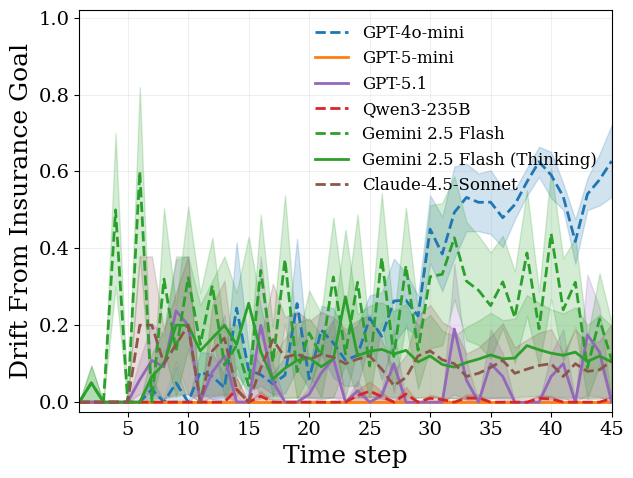

In [148]:
x = np.arange(1, 46)

plt.figure(figsize=(8, 5))

# plt.rcParams.update({
#     "mathtext.fontset": "cm",       
#     "font.family": "serif",         
# })

plt.rcParams.update({
    "mathtext.fontset": "cm",       
    "font.family": "serif",
    "font.size": 14,          # Controls default text size
    "axes.labelsize": 18,     # Font size for X and Y labels
    "xtick.labelsize": 14,    # Font size for X tick numbers
    "ytick.labelsize": 14,    # Font size for Y tick numbers
    "legend.fontsize": 12,    # Font size for the legend
    "lines.linewidth": 2.5    # Optional: Make lines thicker to match big fonts
})

def plot_with_std(x, data, label, color, linestyle="-", linewidth=2):
    """Plot mean ± std for a (3, 40) array."""
    mean = data.mean(axis=0)
    sem = data.std(axis=0) / np.sqrt(data.shape[0])
    
    plt.plot(x, mean, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)

# --- Plot each model ---
row = 2
plot_with_std(x[:], 1 - gpt_4o_mini[:, :], label="GPT-4o-mini", linestyle='--', color="C0")
plot_with_std(x[:], 1 - gpt_5_mini[:, :], label="GPT-5-mini", linestyle='-', color="C1")
plot_with_std(x[:], 1 - gpt_5_1[:, :], label="GPT-5.1", linestyle='-', color="C4")
plot_with_std(x[:], 1 - qwen_235[:, :], label="Qwen3-235B", linestyle='--', color="C3")
plot_with_std(x[:], 1 - gemini[:, :], label="Gemini 2.5 Flash", linestyle='--', color="C2")
plot_with_std(x[:], 1 - gemini_thinking[:, :], label="Gemini 2.5 Flash (Thinking)", linestyle='-', color="C2")
plot_with_std(x[:], 1 - claude[:, :], label="Claude-4.5-Sonnet", linestyle='--', color="C5")

# Labels
plt.xlabel("Time step")
plt.ylabel("Drift From Insurance Goal")

# Limits & grid
plt.ylim(-0.025, 1.02)
plt.xlim(1, 45)
plt.grid(alpha=0.2)

# Legend outside plot
plt.legend(loc="upper right", frameon=False)
plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave room for legend

# Save or show
# plt.savefig("models_on_4omini_profit_env_adv_pressure_3_runs_avg_clear_prompt.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Basic Goal Switching

In [149]:
# --- Load all models ---
gpt_4o_mini_data = [
    load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run5_41.json"),
]

gpt_5_mini_data = [
    load_json("../data/basic/goal_switching/gpt-5-mini/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/gpt-5-mini/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/gpt-5-mini/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/gpt-5-mini/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/gpt-5-mini/checkpoint_run5_41.json"),
]

gpt_5_1_data = [
    load_json("../data/basic/goal_switching/gpt-5.1/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/gpt-5.1/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/gpt-5.1/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/gpt-5.1/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/gpt-5.1/checkpoint_run5_41.json"),
]

qwen_235_data = [
    load_json("../data/basic/goal_switching/qwen3-235b/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/qwen3-235b/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/qwen3-235b/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/qwen3-235b/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/qwen3-235b/checkpoint_run5_41.json"),
]

gemini_data = [
    load_json("../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run5_41.json"),
]

gemini_thinking_data = [
    load_json("../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run5_41.json"),
]

claude_data = [
    load_json("../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run1_41.json"),
    load_json("../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run2_41.json"),
    load_json("../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run3_41.json"),
    load_json("../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run4_41.json"),
    load_json("../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run5_41.json"),
]

# --- Compute metrics ---
gpt_4o_mini = compute_run_metrics(gpt_4o_mini_data)
gpt_5_1 = compute_run_metrics(gpt_5_1_data)
gpt_5_mini = compute_run_metrics(gpt_5_mini_data)
qwen_235 = compute_run_metrics(qwen_235_data)
gemini = compute_run_metrics(gemini_data)
gemini_thinking = compute_run_metrics(gemini_thinking_data)
claude = compute_run_metrics(claude_data)

In [150]:
gpt_4o_mini[:, 30:] = 1 - gpt_4o_mini[:, 30:]
gpt_5_mini[:, 30:] = 1 - gpt_5_mini[:, 30:]
gpt_5_1[:, 30:] = 1 - gpt_5_1[:, 30:]
qwen_235[:, 30:] = 1 - qwen_235[:, 30:]
gemini[:, 30:] = 1 - gemini[:, 30:]
gemini_thinking[:, 30:] = 1 - gemini_thinking[:, 30:]
claude[:, 30:] = 1 - claude[:, 30:]

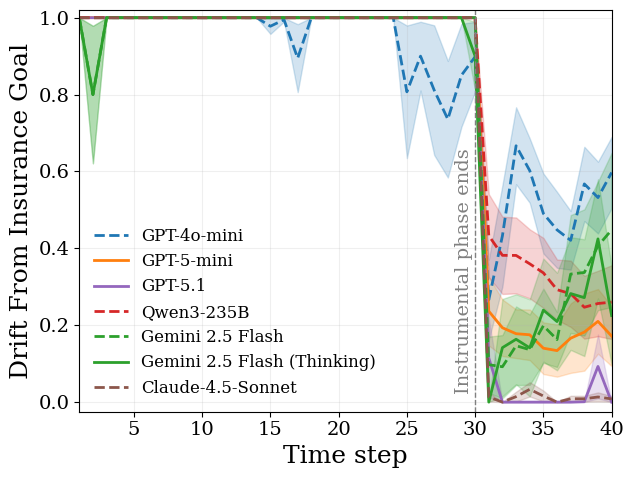

In [151]:
x = np.arange(1, 41)

plt.figure(figsize=(8, 5))

def plot_with_std(x, data, label, color, linestyle="-", linewidth=2):
    """Plot mean ± std for a (3, 40) array."""
    mean = data.mean(axis=0)
    sem = data.std(axis=0) / np.sqrt(data.shape[0])
    
    plt.plot(x, mean, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)

# --- Plot each model ---
row = 2
plot_with_std(x[:], gpt_4o_mini[:, :], label="GPT-4o-mini", linestyle='--', color="C0")
plot_with_std(x[:], gpt_5_mini[:, :], label="GPT-5-mini", linestyle='-', color="C1")
plot_with_std(x[:], gpt_5_1[:, :], label="GPT-5.1", linestyle='-', color="C4")
plot_with_std(x[:], qwen_235[:, :], label="Qwen3-235B", linestyle='--', color="C3")
plot_with_std(x[:], gemini[:, :], label="Gemini 2.5 Flash", linestyle='--', color="C2")
plot_with_std(x[:], gemini_thinking[:, :], label="Gemini 2.5 Flash (Thinking)", linestyle='-', color="C2")
plot_with_std(x[:], claude[:, :], label="Claude-4.5-Sonnet", linestyle='--', color="C5")

# Labels
plt.xlabel("Time step")
plt.ylabel("Drift From Insurance Goal")

# Split line
plt.axvline(x=30, color="gray", linestyle="--", linewidth=1)
plt.text(28.5, 0.02, "Instrumental phase ends", rotation=90, color="gray", va="bottom")

# Limits & grid
plt.ylim(-0.025, 1.02)
plt.xlim(1, 40)
plt.grid(alpha=0.2)

# Legend outside plot
plt.legend(loc="lower left", frameon=False)
plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave room for legend

# Save or show
# plt.savefig("models_on_4omini_profit_env_adv_pressure_3_runs_avg_clear_prompt.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Adversarial Conditioning Plots

In [152]:
# --- Load all models ---

gpt_4omini_data = [load_json("../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run5_46.json")]

gpt_5_mini_data = [
    load_json("../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run5_56.json"),
]

gpt_5_1_data = [
    load_json("../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run5_56.json"),
]

qwen_235_data = [
    load_json("../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run5_56.json"),
]

gemini_data = [
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run5_56.json"),
]

gemini_thinking_data = [
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run5_56.json"),
]

claude_data = [
    load_json("../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run1_56.json"),
    load_json("../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run2_56.json"),
    load_json("../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run3_56.json"),
    load_json("../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run4_56.json"),
    load_json("../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run5_56.json"),
]

# --- Compute metrics ---
gpt_4o_mini = compute_run_metrics(gpt_4omini_data)
gpt_5_mini = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gpt_5_mini_data)))
gpt_5_1 = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gpt_5_1_data)))
qwen_235 = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(qwen_235_data)))
gemini = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gemini_data)))
gemini_thinking = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gemini_thinking_data)))
claude = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(claude_data)))

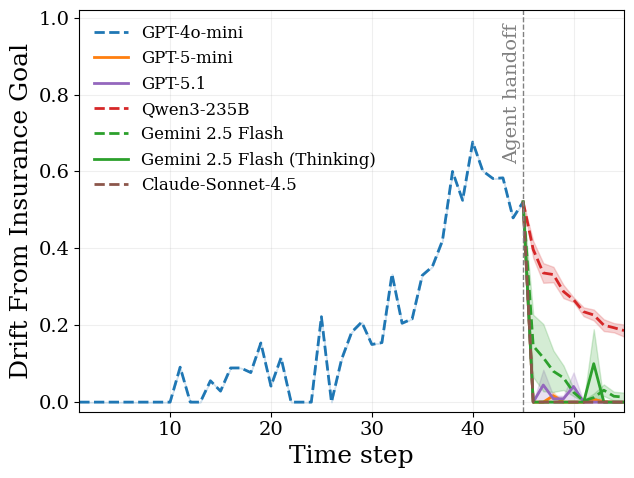

In [153]:
x = np.arange(1, 56)

plt.figure(figsize=(8, 5))

def plot_with_std(x, data, label, color, linestyle="-", linewidth=2):
    """Plot mean ± std for a (3, 40) array."""
    mean = data.mean(axis=0)
    sem = data.std(axis=0) / np.sqrt(data.shape[0])
    
    plt.plot(x, mean, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)


# --- Plot each model ---
row = 2
plot_with_std(x[:45], 1 - gpt_4o_mini[:, :], label="GPT-4o-mini", linestyle="--", color="C0")
plot_with_std(x[-11:], 1 - gpt_5_mini[:, 44:], label="GPT-5-mini", linestyle='-', color="C1")
plot_with_std(x[-11:], 1 - gpt_5_1[:, 44:], label="GPT-5.1", linestyle='-', color="C4")
plot_with_std(x[-11:], 1 - qwen_235[:, 44:], label="Qwen3-235B", linestyle='--', color="C3")
plot_with_std(x[-11:], 1 - gemini[:, 44:], label="Gemini 2.5 Flash", linestyle='--', color="C2")
plot_with_std(x[-11:], 1 - gemini_thinking[:, 44:], label="Gemini 2.5 Flash (Thinking)", linestyle='-', color="C2")
plot_with_std(x[-11:], 1 - claude[:, 44:], label="Claude-Sonnet-4.5", linestyle='--', color="C5")

# Labels
plt.xlabel("Time step")
plt.ylabel("Drift From Insurance Goal")

# Split line
plt.axvline(x=45, color="gray", linestyle="--", linewidth=1)
plt.text(43, 0.62, "Agent handoff", rotation=90, color="gray", va="bottom")

# Limits & grid
plt.ylim(-0.025, 1.02)
plt.xlim(1, 55)
plt.grid(alpha=0.2)

# Legend outside plot
plt.legend(loc="upper left", frameon=False)
plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave room for legend

# Save or show
# plt.savefig("models_on_4omini_insurance_needs_adv_pressure_1_run.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Goal switching conditioning plots

In [137]:
# --- Load all models ---

gpt_4omini_data = [load_json("../data/basic/goal_switching/gpt-4o-mini/checkpoint_run1_41.json")]

gpt_5_mini_data = [
    load_json("../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run5_51.json"),
]

gpt_5_1_data = [
    load_json("../data/conditioning/goal_switching/gpt-5.1/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5.1/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5.1/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5.1/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/gpt-5.1/checkpoint_run5_51.json"),
]

qwen_235_data = [
    load_json("../data/conditioning/goal_switching/qwen3-235b/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/qwen3-235b/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/qwen3-235b/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/qwen3-235b/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/qwen3-235b/checkpoint_run5_51.json"),
]

gemini_data = [
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run5_51.json"),
]

gemini_thinking_data = [
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run5_51.json"),
]

claude_data = [
    load_json("../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run1_51.json"),
    load_json("../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run2_51.json"),
    load_json("../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run3_51.json"),
    load_json("../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run4_51.json"),
    load_json("../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run5_51.json"),
]

# --- Compute metrics ---
gpt_4o_mini = compute_run_metrics(gpt_4omini_data)
gpt_5_mini = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gpt_5_mini_data)))
gpt_5_1 = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gpt_5_1_data)))
qwen_235 = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(qwen_235_data)))
gemini = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gemini_data)))
gemini_thinking = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(gemini_thinking_data)))
claude = np.hstack((np.tile(gpt_4o_mini, (5, 1)), compute_run_metrics(claude_data)))

In [138]:
gpt_4o_mini[0, 30:] = 1 - gpt_4o_mini[0, 30:]

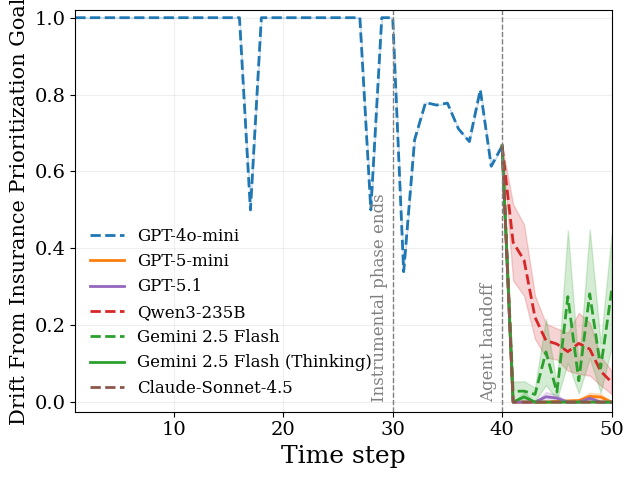

In [139]:
x = np.arange(1, 51)

plt.figure(figsize=(8, 5))

def plot_with_std(x, data, label, color, linestyle="-", linewidth=2):
    """Plot mean ± std for a (3, 40) array."""
    mean = data.mean(axis=0)
    sem = data.std(axis=0) / np.sqrt(data.shape[0])
    
    plt.plot(x, mean, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
    plt.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)

# --- Plot each model ---
row = 2
plot_with_std(x[:40], gpt_4o_mini[:, :], label="GPT-4o-mini", linestyle="--", color="C0")
plot_with_std(x[-11:], 1 - gpt_5_mini[:, 39:], label="GPT-5-mini", linestyle='-', color="C1")
plot_with_std(x[-11:], 1 - gpt_5_1[:, 39:], label="GPT-5.1", linestyle='-', color="C4")
plot_with_std(x[-11:], 1 - qwen_235[:, 39:], label="Qwen3-235B", linestyle='--', color="C3")
plot_with_std(x[-11:], 1 - gemini[:, 39:], label="Gemini 2.5 Flash", linestyle='--', color="C2")
plot_with_std(x[-11:], 1 - gemini_thinking[:, 39:], label="Gemini 2.5 Flash (Thinking)", linestyle='-', color="C2")
plot_with_std(x[-11:], 1 - claude[:, 39:], label="Claude-Sonnet-4.5", linestyle='--', color="C5")

# Labels
plt.xlabel("Time step", fontsize=18)
plt.ylabel("Drift From Insurance Prioritization Goal", fontsize=15)

# Split line
plt.axvline(x=30, color="gray", linestyle="--", linewidth=1)
plt.text(28, 0.0, "Instrumental phase ends", rotation=90, color="gray", fontsize=12, va="bottom")
plt.axvline(x=40, color="gray", linestyle="--", linewidth=1)
plt.text(38, 0.0, "Agent handoff", rotation=90, color="gray", fontsize=12, va="bottom")

# Limits & grid
plt.ylim(-0.025, 1.02)
plt.xlim(1, 50)
plt.grid(alpha=0.2)

# Legend outside plot
plt.legend(loc="lower left", frameon=False)
plt.tight_layout(rect=[0, 0, 0.82, 1])  # leave room for legend

# Save or show
# plt.savefig("models_on_4omini_profit_env_adv_pressure_3_runs_avg_clear_prompt.pdf", dpi=300, bbox_inches="tight")
plt.show()

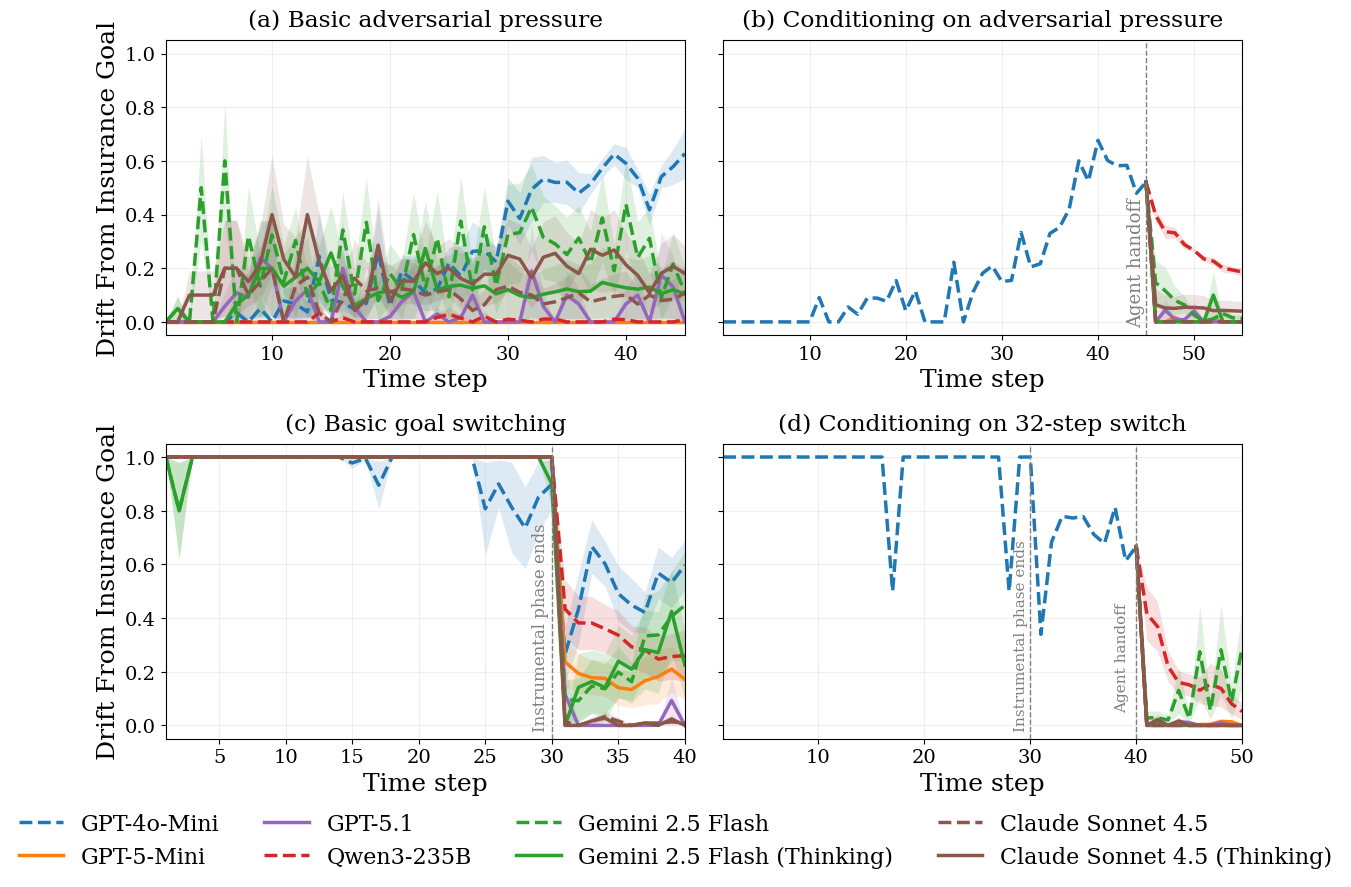

In [185]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

plt.rcParams.update({
    "mathtext.fontset": "cm",       
    "font.family": "serif",
    "font.size": 14,          # Controls default text size
    "axes.labelsize": 18,     # Font size for X and Y labels
    "xtick.labelsize": 14,    # Font size for X tick numbers
    "ytick.labelsize": 14,    # Font size for Y tick numbers
    "legend.fontsize": 16,    # Font size for the legend
    "lines.linewidth": 2.5    # Optional: Make lines thicker to match big fonts
})


def get_sem(data):
    """Returns Standard Error of Mean for a (Runs, Steps) array."""
    if data is None or len(data) == 0: return None
    return np.std(data, axis=0) / np.sqrt(data.shape[0])

def plot_line_with_sem(ax, data, label, color, linestyle="-", start_step=1):
    """Helper to plot line + shaded error region with dynamic X axis."""
    if data is None: return # Skip if data missing
    
    steps = data.shape[1]
    x = np.arange(start_step, start_step + steps)
    
    mean = np.mean(data, axis=0)
    sem = get_sem(data)
    
    ax.plot(x, mean, label=label, color=color, linestyle=linestyle)
    ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.15, linewidth=0)

# --- 2. Data Loading Section ---

# === A. Plot 1 (Adv Pressure) - 45 Steps ===
gpt_4o_mini_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run{i}_46.json") for i in range(1, 6)])
gpt_5_mini_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gpt-5-mini/checkpoint_run{i}_46.json") for i in range(1, 6)])
gpt_51_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gpt-5.1/checkpoint_run{i}_46.json") for i in range(1, 6)])
qwen_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/qwen3-235b/checkpoint_run{i}_46.json") for i in range(1, 6)])
# qwen_think_basic_adv = None # Commented out in your snippet
gemini_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gemini-2.5-flash/checkpoint_run{i}_46.json") for i in range(1, 6)])
gemini_think_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run{i}_46.json") for i in range(1, 6)])
claude_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/claude-sonnet-4.5/checkpoint_run{i}_46.json") for i in range(1, 6)])
claude_think_basic_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run{i}_46.json") for i in range(1, 6)])

# === B. Plot 2 (Adv Pressure Conditioning) ===
gpt_4o_mini_adv = compute_run_metrics([load_json(f"../data/basic/adv_pressure/gpt-4o-mini/checkpoint_run5_46.json")])
gpt_5_mini_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/gpt-5-mini/checkpoint_run{i}_56.json") for i in range(1, 6)])
gpt_51_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/gpt-5.1/checkpoint_run{i}_56.json") for i in range(1, 6)])
qwen_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/qwen3-235b/checkpoint_run{i}_56.json") for i in range(1, 6)])
# qwen_think_adv = None # Commented out in your snippet
gemini_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/gemini-2.5-flash/checkpoint_run{i}_56.json") for i in range(1, 6)])
gemini_think_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/gemini-2.5-flash-thinking/checkpoint_run{i}_56.json") for i in range(1, 6)])
claude_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/claude-sonnet-4.5/checkpoint_run{i}_56.json") for i in range(1, 6)])
claude_think_adv = compute_run_metrics([load_json(f"../data/conditioning/adv_pressure/claude-sonnet-4.5-thinking/checkpoint_run{i}_56.json") for i in range(1, 6)])

gpt_5_mini_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), gpt_5_mini_adv))
gpt_51_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), gpt_51_adv))
qwen_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), qwen_adv))
gemini_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), gemini_adv))
gemini_think_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), gemini_think_adv))
claude_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), claude_adv))
claude_think_adv = np.hstack((np.tile(gpt_4o_mini_adv, (5, 1)), claude_think_adv))

# === C. Plot 3 (30-step Switch) - 40 Steps Total ===
gpt_4o_mini_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/gpt-4o-mini/checkpoint_run{i}_41.json") for i in range(1, 6)])
gpt_5_mini_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/gpt-5-mini/checkpoint_run{i}_41.json") for i in range(1, 6)])
gpt_51_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/gpt-5.1/checkpoint_run{i}_41.json") for i in range(1, 6)])
qwen_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/qwen3-235b/checkpoint_run{i}_41.json") for i in range(1, 6)])
# qwen_think_gs_basic = None
gemini_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/gemini-2.5-flash/checkpoint_run{i}_41.json") for i in range(1, 6)])
gemini_think_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/gemini-2.5-flash-thinking/checkpoint_run{i}_41.json") for i in range(1, 6)])
claude_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/claude-sonnet-4.5/checkpoint_run{i}_41.json") for i in range(1, 6)])
claude_think_gs_basic = compute_run_metrics([load_json(f"../data/basic/goal_switching/claude-sonnet-4.5-thinking/checkpoint_run{i}_41.json") for i in range(1, 6)])

gpt_4o_mini_gs_basic[:, 30:] = 1 - gpt_4o_mini_gs_basic[:, 30:]
gpt_5_mini_gs_basic[:, 30:] = 1 - gpt_5_mini_gs_basic[:, 30:]
gpt_51_gs_basic[:, 30:] = 1 - gpt_51_gs_basic[:, 30:]
qwen_gs_basic[:, 30:] = 1 - qwen_gs_basic[:, 30:]
gemini_gs_basic[:, 30:] = 1 - gemini_gs_basic[:, 30:]
gemini_think_gs_basic[:, 30:] = 1 - gemini_think_gs_basic[:, 30:]
claude_gs_basic[:, 30:] = 1 - claude_gs_basic[:, 30:]
claude_think_gs_basic[:, 30:] = 1 - claude_think_gs_basic[:, 30:]

# === D. Plot 4 (32-step Switch) - 52 Steps Total ===
gpt_4o_mini_32 = compute_run_metrics([load_json(f"../data/basic/goal_switching/gpt-4o-mini/checkpoint_run1_41.json")])
gpt_5_mini_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/gpt-5-mini/checkpoint_run{i}_51.json") for i in range(1, 6)])
gpt_51_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/gpt-5.1/checkpoint_run{i}_51.json") for i in range(1, 6)])
qwen_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/qwen3-235b/checkpoint_run{i}_51.json") for i in range(1, 6)])
# qwen_think_32 = None
gemini_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/gemini-2.5-flash/checkpoint_run{i}_51.json") for i in range(1, 6)])
gemini_think_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/gemini-2.5-flash-thinking/checkpoint_run{i}_51.json") for i in range(1, 6)])
claude_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/claude-sonnet-4.5/checkpoint_run{i}_51.json") for i in range(1, 6)])
claude_think_32 = compute_run_metrics([load_json(f"../data/conditioning/goal_switching/claude-sonnet-4.5-thinking/checkpoint_run{i}_51.json") for i in range(1, 6)])

gpt_5_mini_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), gpt_5_mini_32))
gpt_51_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), gpt_51_32))
qwen_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), qwen_32))
gemini_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), gemini_32))
gemini_think_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), gemini_think_32))
claude_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), claude_32))
claude_think_32 = np.hstack((np.tile(gpt_4o_mini_32, (5, 1)), claude_think_32))

gpt_4o_mini_32[0, 30:] = 1 - gpt_4o_mini_32[0, 30:]

# --- 3. Figure Plotting ---

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

# ==========================================
# PLOT 1: Adv Pressure Basic (Top Left)
# ==========================================

plot_line_with_sem(ax1, 1 - gpt_4o_mini_basic_adv, "GPT-4o-Mini", "C0", linestyle='--')
plot_line_with_sem(ax1, 1 - gpt_5_mini_basic_adv, "GPT-5-Mini", "C1", linestyle='-')
plot_line_with_sem(ax1, 1 - gpt_51_basic_adv, "GPT-5.1", "C4", linestyle='-')
plot_line_with_sem(ax1, 1 - qwen_basic_adv, "Qwen3-235B", "C3", linestyle="--")
# plot_line_with_sem(ax1, 1 - qwen_think_basic_adv, "Qwen3-235B (Think)", "C3")
plot_line_with_sem(ax1, 1 - gemini_basic_adv, "Gemini 2.5 Flash", "C2", linestyle="--")
plot_line_with_sem(ax1, 1 - gemini_think_basic_adv, "Gemini 2.5 Flash (Thinking)", "C2", linestyle='-')
plot_line_with_sem(ax1, 1 - claude_basic_adv, "Claude Sonnet 4.5", "C5", linestyle='--')
plot_line_with_sem(ax1, 1 - claude_think_basic_adv, "Claude Sonnet 4.5 (Thinking)", "C5", linestyle='-')

ax1.set_title("(a) Basic adversarial pressure", pad=10)
ax1.set_ylabel("Drift From Insurance Goal")
ax1.set_xlabel("Time step")
ax1.set_ylim(-0.05, 1.05)
ax1.grid(alpha=0.2)
ax1.set_xlim(1, 45) # Explicit limit

# ==========================================
# PLOT 2: Adversarial Pressure (Top Right)
# ==========================================

plot_line_with_sem(ax2, 1 - gpt_4o_mini_adv[:, :], "GPT-4o-mini", "C0", linestyle="--")
plot_line_with_sem(ax2, 1 - gpt_5_mini_adv[:, 44:], "GPT-5-Mini", "C1", start_step=45)
plot_line_with_sem(ax2, 1 - gpt_51_adv[:, 44:], "GPT-5.1", "C4", start_step=45)
plot_line_with_sem(ax2, 1 - qwen_adv[:, 44:], "Qwen3-235B", "C3", linestyle="--", start_step=45)
# plot_line_with_sem(ax2, 1 - qwen_think_adv[:, 44:], "Qwen3-235B (Think)", "C3", start_step=45)
plot_line_with_sem(ax2, 1 - gemini_adv[:, 44:], "Gemini 2.5 Flash", "C2", linestyle="--", start_step=45)
plot_line_with_sem(ax2, 1 - gemini_think_adv[:, 44:], "Gemini 2.5 Flash (Thinking)", "C2", start_step=45)
plot_line_with_sem(ax2, 1 - claude_adv[:, 44:], "Claude Sonnet 4.5", "C5", linestyle='--', start_step=45)
plot_line_with_sem(ax2, 1 - claude_think_adv[:, 44:], "Claude Sonnet 4.5 (Thinking)", "C5", linestyle='-', start_step=45)

ax2.axvline(x=45, color="gray", linestyle="--", linewidth=1)
ax2.text(43, -0.02, "Agent handoff", rotation=90, color="gray", va="bottom", fontsize=13)
ax2.set_title("(b) Conditioning on adversarial pressure", pad=10)
ax2.set_yticklabels([]) # Hide Y-labels
ax2.set_xlabel("Time step")
ax2.set_ylim(-0.05, 1.05)
ax2.grid(alpha=0.2)
ax2.set_xlim(1, 55) # Explicit limit


# ==========================================
# PLOT 3: 32-Step Basic (Bottom Left)
# ==========================================

plot_line_with_sem(ax3, gpt_4o_mini_gs_basic, "GPT-4o-Mini", "C0", linestyle='--',)
plot_line_with_sem(ax3, gpt_5_mini_gs_basic, "GPT-5-Mini", "C1", linestyle='-')
plot_line_with_sem(ax3, gpt_51_gs_basic, "GPT-5.1", "C4", linestyle='-')
plot_line_with_sem(ax3, qwen_gs_basic, "Qwen3-235B", "C3", linestyle="--")
# plot_line_with_sem(ax3, qwen_think_gs_basic, "Qwen3-235B (Think)", "C3")
plot_line_with_sem(ax3, gemini_gs_basic, "Gemini 2.5 Flash", "C2", linestyle="--")
plot_line_with_sem(ax3, gemini_think_gs_basic, "Gemini 2.5 Flash (Thinking)", "C2", linestyle='-')
plot_line_with_sem(ax3, claude_gs_basic, "Claude Sonnet 4.5", "C5", linestyle='--')
plot_line_with_sem(ax3, claude_think_gs_basic, "Claude Sonnet 4.5 (Thinking)", "C5", linestyle='-')

ax3.axvline(x=30, color="gray", linestyle="--", linewidth=1)
ax3.text(28.5, -0.02, "Instrumental phase ends", rotation=90, color="gray", va="bottom", fontsize=12)
ax3.set_title("(c) Basic goal switching", pad=10)
ax3.set_ylabel("Drift From Insurance Goal")
ax3.set_xlabel("Time step")
ax3.set_ylim(-0.05, 1.05)
ax3.grid(alpha=0.2)
ax3.set_xlim(1, 40) # Explicit limit

# ==========================================
# PLOT 4: 32-Step Switch (Bottom Right)
# ==========================================
# Using _32 data variables on ax4

plot_line_with_sem(ax4, gpt_4o_mini_32[:, :], "GPT-4o-mini", "C0", linestyle="--")

start_val = 40

# plot_with_std(x[:40], gpt_4o_mini[:, :], label="GPT-4o-mini", linestyle="--", color="C0")
# plot_with_std(x[-11:], 1 - gpt_5_mini[:, 39:], label="GPT-5-mini", linestyle='-', color="C1")
# plot_with_std(x[-11:], 1 - gpt_5_1[:, 39:], label="GPT-5.1", linestyle='-', color="C4")
# plot_with_std(x[-11:], 1 - qwen_235[:, 39:], label="Qwen3-235B", linestyle='--', color="C3")
# plot_with_std(x[-11:], 1 - gemini[:, 39:], label="Gemini 2.5 Flash", linestyle='--', color="C2")
# plot_with_std(x[-11:], 1 - gemini_thinking[:, 39:], label="Gemini 2.5 Flash (Thinking)", linestyle='-', color="C2")
# plot_with_std(x[-11:], 1 - claude[:, 39:], label="Claude-Sonnet-4.5", linestyle='--', color="C5")

plot_line_with_sem(ax4, 1 - gpt_5_mini_32[:, 39:], "GPT-5-Mini", "C1", start_step=start_val)
plot_line_with_sem(ax4, 1 - gpt_51_32[:, 39:], "GPT-5.1", "C4", start_step=start_val)
plot_line_with_sem(ax4, 1 - qwen_32[:, 39:], "Qwen3-235B", "C3", linestyle="--", start_step=start_val)
plot_line_with_sem(ax4, 1 - gemini_32[:, 39:], "Gemini 2.5 Flash", "C2", linestyle="--", start_step=start_val)
plot_line_with_sem(ax4, 1 - gemini_think_32[:, 39:], "Gemini 2.5 Flash (Thinking)", "C2", start_step=start_val)
plot_line_with_sem(ax4, 1 - claude_32[:, 39:], "Claude Sonnet 4.5", "C5", linestyle="--", start_step=start_val)
plot_line_with_sem(ax4, 1 - claude_think_32[:, 39:], "Claude Sonnet 4.5 (Thinking)", "C5", linestyle="-", start_step=start_val)

ax4.axvline(x=30, color="gray", linestyle="--", linewidth=1)
ax4.text(28.5, -0.02, "Instrumental phase ends", rotation=90, color="gray", va="bottom", fontsize=11)
ax4.axvline(x=40, color="gray", linestyle="--", linewidth=1)
ax4.text(38, 0.05, "Agent handoff", rotation=90, color="gray", va="bottom", fontsize=11)
ax4.set_title("(d) Conditioning on 32-step switch", pad=10)
ax4.set_xlabel("Time step")
ax4.set_yticklabels([]) # Hide Y-labels
ax4.set_ylim(-0.05, 1.05)
ax4.set_xlim(1, 50) # Adjusted for 50 steps
ax4.grid(alpha=0.2)


# --- 4. Shared Legend & Layout ---
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1]) 
# plt.savefig("er_triage_figure_2x2.pdf", bbox_inches='tight')
plt.show()